## FIGURE 4 FOR WUS WARMING PAPER

In [2]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
os.environ['ESMFMKFILE'] = '/home/tessj/miniconda3/envs/xarrayxesmf/lib/esmf.mk'
import xesmf as xe
import numpy as np
#import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns
import json
import xskillscore as xsc

def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

In [3]:
import cftime
def to_dt64(ds, timevar='time', unit='months since 1979-01-01'):
    ds[timevar] = cftime.num2date(ds[timevar], unit, '360_day')
    ds[timevar] = ds.indexes[timevar].to_datetimeindex()
    return ds

In [4]:
modmembers_geq3_tas = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_tas_total.json', 'r') as file:
        modmembers_geq3_tas = json.load(file)
        
modmembers_geq3_hfls = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_hfls_total.json', 'r') as file:
        modmembers_geq3_hfls = json.load(file)

modmembers_geq3_pr = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_pr_total.json', 'r') as file:
        modmembers_geq3_pr = json.load(file)
        
modmembers_geq3_prw = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_prw_total.json', 'r') as file:
        modmembers_geq3_prw = json.load(file)

### open obs temperature data

In [5]:
tas_test = xr.open_dataset(f'/d3/tessj/data/CMIP6/for_tess/ACCESS-ESM1-5/tas_Amon_ACCESS-ESM1-5_historical_r3i1p1f1_18500101-20141231_regrid.nc').sel(time=slice('1941-01-01', '2014-12-31'))
landmask = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.interp_like(tas_test)
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

/tmp/ipykernel_30944/386567312.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  landmask = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])


In [6]:
wusbox = [-125, -102, 32,  49]

In [7]:
weights = np.cos(np.deg2rad(landmask.lat))

In [8]:
datetimes_np64 = np.arange('1941-01', '2025-01', dtype='datetime64[M]')
datetimes_np64 = datetimes_np64.astype('datetime64[ns]')

In [9]:
gisstemp = xr.open_dataset('/home/tessj/wus_temp_trends/gistemp250_GHCNv4.nc').sel(time=slice('1941-01-01', '2024-12-31')).assign_coords({'time':datetimes_np64}).drop('time_bnds')

/tmp/ipykernel_30944/475215526.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  gisstemp = xr.open_dataset('/home/tessj/wus_temp_trends/gistemp250_GHCNv4.nc').sel(time=slice('1941-01-01', '2024-12-31')).assign_coords({'time':datetimes_np64}).drop('time_bnds')


In [10]:
gisstemp_wus = gisstemp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
gisstemp_weights = np.cos(np.deg2rad(gisstemp.lat))

gisstemp_wus_avg = gisstemp_wus.weighted(gisstemp_weights).mean(['lon','lat'])
gisstemp_globland_avg = gisstemp.weighted(gisstemp_weights).mean(['lon','lat'])

In [11]:
gisstemp_wus_avg_trend = gisstemp_wus_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
gisstemp_globland_avg_trend = gisstemp_globland_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [12]:
gisstemp_wus_avg_szn = {}
gisstemp_globland_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_szn[szn] = gisstemp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    gisstemp_globland_avg_szn[szn] = gisstemp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [13]:
gisstemp_wus_avg_szn = {}
gisstemp_globland_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_szn[szn] = gisstemp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    gisstemp_globland_avg_szn[szn] = gisstemp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [14]:
gisstemp_wus_avg_trend_szn = {}
gisstemp_globland_avg_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_trend_szn[szn] = gisstemp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    gisstemp_globland_avg_trend_szn[szn] = gisstemp_globland_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [15]:
berk_temp = xr.open_dataset('/home/tessj/wus_temp_trends/Complete_TAVG_LatLong1.nc', decode_times=True).isel(time=slice(12*191,3300)).assign_coords({'time':gisstemp.time}).rename({'latitude':'lat', 'longitude':'lon'})

In [16]:
berk_temp_wus = berk_temp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
berk_temp_na = berk_temp.sel(lon=slice(wusbox[0],-90), lat=slice(20,60))

berk_temp_weights = np.cos(np.deg2rad(berk_temp.lat))

berk_temp_wus_avg = berk_temp_wus.weighted(berk_temp_weights).mean(['lon','lat'])
berk_temp_globland_avg = berk_temp.weighted(berk_temp_weights).mean(['lon','lat'])

In [17]:
berk_temp_wus_avg_trend = berk_temp_wus_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
berk_temp_globland_avg_trend = berk_temp_globland_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [18]:
berk_temp_wus_avg_szn = {}
berk_temp_globland_avg_szn = {}
berk_temp_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_szn[szn] = berk_temp_na.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_wus_avg_szn[szn] = berk_temp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_globland_avg_szn[szn] = berk_temp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [19]:
berk_temp_wus_avg_trend_szn = {}
berk_temp_globland_avg_trend_szn = {}
berk_temp_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_globland_avg_trend_szn[szn] = berk_temp_globland_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_wus_trend_szn[szn] = berk_temp_wus_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [20]:
berk_temp_wus_avg_trend_szn_2021end = {}
berk_temp_globland_avg_trend_szn_2021end = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_szn_2021end[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_globland_avg_trend_szn_2021end[szn] = berk_temp_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [21]:
[berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients.item()*45 for szn in berk_temp_wus_avg_trend_szn.keys()]

[0.3317690127687514, 0.658451650063264, 1.8910986129076108, 1.1415742399361546]

In [22]:
np.mean([berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients.item()*45 for szn in berk_temp_wus_avg_trend_szn.keys()])

1.0057233789189453

In [23]:
berk_temp_wus_avg_trend_80_14_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_80_14_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2014-12-31')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


### open CMIP6 data

In [24]:
ds_tas_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_avgs.nc')
ds_tas_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_na.nc')

In [25]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim


In [26]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim

ds_tas_avg_m_clim = ds_tas_avg.groupby('time.month').mean('time')
ds_tas_avg_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_m_clim

In [27]:
ds_tas_wus_51_80_m_clim = ds_tas_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_wus_51_80_m_anom = ds_tas_wus.groupby('time.month') - ds_tas_wus_51_80_m_clim

In [28]:
45*(ds_tas_avg_51_80_m_anom.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)).mean('model')

<xarray.Dataset> Size: 24B
Dimensions:                            ()
Coordinates:
    degree                             int64 8B 1
Data variables:
    tas_globland_polyfit_coefficients  float64 8B 1.66
    tas_wus_polyfit_coefficients       float64 8B 1.902

In [29]:
45*(ds_tas_avg_51_80_m_anom.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)).max()

<xarray.Dataset> Size: 24B
Dimensions:                            ()
Coordinates:
    degree                             int64 8B 1
Data variables:
    tas_globland_polyfit_coefficients  float64 8B 2.52
    tas_wus_polyfit_coefficients       float64 8B 2.874

In [30]:
ds_tas_avg_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_szn[szn] = ds_tas_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [31]:
ds_tas_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_trend_szn[szn] = ds_tas_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [32]:
ds_tas_avg_51_80_m_anom_trend_szn_2021end = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn] = ds_tas_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [33]:
ds_pr_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_pr_na.nc')

In [34]:
ds_pr_wus_51_80_m_clim = ds_pr_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_pr_wus_51_80_m_anom = ds_pr_wus.groupby('time.month') - ds_pr_wus_51_80_m_clim

In [35]:
ds_pr_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_pr_wus_51_80_m_anom_szn[szn] = ds_pr_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [36]:
ds_pr_wus_51_80_m_anom_trend_szn = {}
ds_pr_wus_51_80_m_anom_trend_szn_2021end = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_pr_wus_51_80_m_anom_trend_szn[szn] = ds_pr_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_pr_wus_51_80_m_anom_trend_szn_2021end[szn] = ds_pr_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [37]:
ds_prw_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_prw_na.nc')

In [38]:
ds_prw_wus_51_80_m_clim = ds_prw_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_prw_wus_51_80_m_anom = ds_prw_wus.groupby('time.month') - ds_prw_wus_51_80_m_clim

In [39]:
ds_prw_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_prw_wus_51_80_m_anom_szn[szn] = ds_prw_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [40]:
ds_prw_wus_51_80_m_anom_trend_szn = {}
ds_prw_wus_51_80_m_anom_trend_szn_2021end = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_prw_wus_51_80_m_anom_trend_szn[szn] = ds_prw_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_prw_wus_51_80_m_anom_trend_szn_2021end[szn] = ds_prw_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [41]:
ds_e_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_e_na.nc')

In [42]:
ds_e_wus_51_80_m_clim = ds_e_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_e_wus_51_80_m_anom = ds_e_wus.groupby('time.month') - ds_e_wus_51_80_m_clim

In [43]:
ds_e_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_e_wus_51_80_m_anom_szn[szn] = ds_e_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [44]:
ds_e_wus_51_80_m_anom_trend_szn = {}
ds_e_wus_51_80_m_anom_trend_szn_2021end = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_e_wus_51_80_m_anom_trend_szn[szn] = ds_e_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_e_wus_51_80_m_anom_trend_szn_2021end[szn] = ds_e_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


### open ERA5 data

In [45]:
era5_sl_wus= xr.open_dataset('/home/tessj/wus_temp_trends/era5_slvars_1940_2024_na.nc')[['tp','e']].load()

In [46]:
era5_tcwv = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_tcwv_1940_2025.nc')[['tcwv']].load()
era5_tcwv = fix_coords_lon(era5_tcwv).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])
era5_tcwv = era5_tcwv.assign_coords(time=era5_sl_wus.time)

/tmp/ipykernel_30944/2767758806.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  era5_tcwv = fix_coords_lon(era5_tcwv).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])


In [47]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_tcwv.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [48]:
era5_sl_wus_51_80_m_clim = era5_sl_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
era5_sl_wus_51_80_m_anom = era5_sl_wus.groupby('time.month') - era5_sl_wus_51_80_m_clim

In [49]:
era5_weights = np.cos(np.deg2rad(era5_sl_wus.lat))
landmask = fix_coords_lon(xr.open_dataarray('/net/kage/d4/naomi/DataCatalog/ERA5/monthly/single_level/y1979-2020/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

/tmp/ipykernel_30944/1984425795.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  landmask = fix_coords_lon(xr.open_dataarray('/net/kage/d4/naomi/DataCatalog/ERA5/monthly/single_level/y1979-2020/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])


In [50]:
era5_sl_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_szn[szn] = era5_sl_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [51]:
era5_sl_wus_51_80_m_anom_trend_szn = {}
era5_sl_wus_51_80_m_anom_trend_pvalue_szn = {}

era5_sl_wus_51_80_m_anom_trend_szn_2021end = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_trend_szn[szn] = era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    era5_sl_wus_51_80_m_anom_trend_pvalue_szn[szn] = xsc.pearson_r_p_value(era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time'),
                                                                           era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').year,
                                                                           dim='year')
    era5_sl_wus_51_80_m_anom_trend_szn_2021end[szn] = era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2021-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [52]:
era5_pme_wus_51_80_m_anom_trend_pvalue_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_pme_wus_51_80_m_anom_trend_pvalue_szn[szn]= xsc.pearson_r_p_value(era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').tp +
                                                                           era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').e,
                                                                           era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').year,
                                                                           dim='year')


### Open CAM6 data and calculate trends

In [53]:
cam6_ds_t2m = xr.open_dataarray('/d4/tessj/data/CAM6/monthly/trefht_ens.nc')
cam6_ds_prectot = xr.open_dataarray('/d4/tessj/data/CAM6/monthly/prectot_ens.nc')
cam6_ds_lhflx = xr.open_dataarray('/d4/tessj/data/CAM6/monthly/lhflx_ens.nc')

In [54]:
cam6_ds_prw = xr.open_dataarray('/d5/tessj/data/CAM6/tmq_ens.nc')

In [55]:
cam6_prw_mean = xr.open_dataset(f'http://hodges.ldeo.columbia.edu:81/SOURCES/.CAM6/.forRichard/.CAM6/.runs/.ensemble-extension-to-aug2021/.atm/.mean/.SLD/.TMQ.nc/.TMQ/dods',
                               decode_times=False)

In [56]:
cam6_ds_prw = fix_coords_lon_lat(cam6_ds_prw)

In [57]:
cam6_ds_lhflx = fix_coords_lon_lat(cam6_ds_lhflx)

In [58]:
cam6_ds_prectot = fix_coords_lon_lat(cam6_ds_prectot)

In [59]:
cam6_ds_pr = cam6_ds_prectot

In [60]:
cam6_ds_t2m = fix_coords_lon_lat(cam6_ds_t2m)

In [61]:
cam6_ds_e = (86400*1e-6)*(cam6_ds_lhflx)/(2.501-((2.361e-3)*(cam6_ds_t2m - 273.15)))

In [62]:
cam6_prw_mean = fix_coords_lon_lat(cam6_prw_mean)
cam6_prw_mean = to_dt64(cam6_prw_mean)

/tmp/ipykernel_30944/3691984310.py:4: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, '360_day', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds[timevar] = ds.indexes[timevar].to_datetimeindex()


In [63]:
cam6_landmask = landmask.interp_like(cam6_ds_t2m)

In [64]:
cam6_ds_t2m_m_clim = cam6_ds_t2m.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_ds_t2m_anom = cam6_ds_t2m.groupby('time.month') - cam6_ds_t2m_m_clim

In [65]:
cam6_ds_t2m_wus = cam6_ds_t2m_anom.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_ds_t2m_weights = np.cos(np.deg2rad(cam6_ds_t2m.lat))
cam6_ds_t2m_wus_avg = cam6_ds_t2m_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_t2m_weights).mean(['lon','lat'])
cam6_ds_t2m_na = cam6_ds_t2m_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

cam6_ds_t2m_globland_avg = cam6_ds_t2m_anom.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_t2m_weights).mean(['lon','lat'])

#being lazy 
cam6_ds_t2m_wus = cam6_ds_t2m_na

In [66]:
cam6_ds_t2m_wus_avg_trend = cam6_ds_t2m_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_ds_t2m_globland_avg_trend = cam6_ds_t2m_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [67]:
cam6_ds_t2m_wus_avg_szn = {}
cam6_ds_t2m_globland_avg_szn = {}
cam6_ds_t2m_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_szn[szn] = cam6_ds_t2m_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_t2m_wus_avg_szn[szn] = cam6_ds_t2m_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_t2m_globland_avg_szn[szn] = cam6_ds_t2m_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [68]:
cam6_ds_t2m_wus_avg_trend_szn = {}
cam6_ds_t2m_globland_avg_trend_szn = {}
cam6_ds_t2m_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_avg_trend_szn[szn] = cam6_ds_t2m_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_t2m_globland_avg_trend_szn[szn] = cam6_ds_t2m_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_t2m_wus_trend_szn[szn] = cam6_ds_t2m_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [69]:
cam6_ds_t2m_wus_avg_ensmean_szn = {}
cam6_ds_t2m_globland_avg_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_avg_ensmean_szn[szn] = cam6_ds_t2m_wus_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    cam6_ds_t2m_globland_avg_ensmean_szn[szn] = cam6_ds_t2m_globland_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [70]:
cam6_ds_t2m_wus_avg_trend_ensmean_szn = {}
cam6_ds_t2m_globland_avg_trend_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_avg_trend_ensmean_szn[szn] = cam6_ds_t2m_wus_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_t2m_globland_avg_trend_ensmean_szn[szn] = cam6_ds_t2m_globland_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [71]:
cam6_ds_pr_m_clim = cam6_ds_pr.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_ds_pr_anom = cam6_ds_pr.groupby('time.month') - cam6_ds_pr_m_clim

In [72]:
cam6_ds_pr_wus = cam6_ds_pr_anom.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_ds_pr_weights = np.cos(np.deg2rad(cam6_ds_pr.lat))
cam6_ds_pr_wus_avg = cam6_ds_pr_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_pr_weights).mean(['lon','lat'])
cam6_ds_pr_globland_avg = cam6_ds_pr_anom.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_pr_weights).mean(['lon','lat'])

cam6_ds_pr_na = cam6_ds_pr_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

cam6_ds_pr_wus = cam6_ds_pr_na

In [73]:
cam6_ds_pr_wus_avg_trend = cam6_ds_pr_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_ds_pr_globland_avg_trend = cam6_ds_pr_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [74]:
cam6_ds_pr_wus_avg_szn = {}
cam6_ds_pr_globland_avg_szn = {}
cam6_ds_pr_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_pr_wus_szn[szn] = cam6_ds_pr_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_pr_wus_avg_szn[szn] = cam6_ds_pr_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_pr_globland_avg_szn[szn] = cam6_ds_pr_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [75]:
cam6_ds_pr_wus_avg_trend_szn = {}
cam6_ds_pr_globland_avg_trend_szn = {}
cam6_ds_pr_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_pr_wus_avg_trend_szn[szn] = cam6_ds_pr_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_pr_globland_avg_trend_szn[szn] = cam6_ds_pr_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_pr_wus_trend_szn[szn] = cam6_ds_pr_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [76]:
cam6_ds_e_m_clim = cam6_ds_e.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_ds_e_anom = cam6_ds_e.groupby('time.month') - cam6_ds_e_m_clim

In [77]:
cam6_ds_e_wus = cam6_ds_e_anom.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_ds_e_weights = np.cos(np.deg2rad(cam6_ds_pr.lat))
cam6_ds_e_wus_avg = cam6_ds_e_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_e_weights).mean(['lon','lat'])
cam6_ds_e_globland_avg = cam6_ds_e_anom.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_e_weights).mean(['lon','lat'])

cam6_ds_e_na = cam6_ds_e_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

cam6_ds_e_wus = cam6_ds_e_na

In [78]:
cam6_ds_e_wus_avg_trend = cam6_ds_e_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_ds_e_globland_avg_trend = cam6_ds_e_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [79]:
cam6_ds_e_wus_avg_szn = {}
cam6_ds_e_globland_avg_szn = {}
cam6_ds_e_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_e_wus_szn[szn] = cam6_ds_e_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_e_wus_avg_szn[szn] = cam6_ds_e_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_e_globland_avg_szn[szn] = cam6_ds_e_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [80]:
cam6_ds_e_wus_avg_trend_szn = {}
cam6_ds_e_globland_avg_trend_szn = {}
cam6_ds_e_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_e_wus_avg_trend_szn[szn] = cam6_ds_e_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_e_globland_avg_trend_szn[szn] = cam6_ds_e_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_e_wus_trend_szn[szn] = cam6_ds_e_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [81]:
cam6_prw_mean_m_clim = cam6_prw_mean.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_prw_mean_anom = cam6_prw_mean.groupby('time.month') - cam6_prw_mean_m_clim

In [82]:
cam6_prw_mean_wus = cam6_prw_mean.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_prw_mean_weights = np.cos(np.deg2rad(cam6_prw_mean.lat))
cam6_prw_mean_wus_avg = cam6_prw_mean_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_prw_mean_weights).mean(['lon','lat'])
cam6_prw_mean_globland_avg = cam6_prw_mean.where(cam6_landmask==cam6_landmask).weighted(cam6_prw_mean_weights).mean(['lon','lat'])
cam6_prw_mean_na = cam6_prw_mean_anom.sel(lat=slice(0,65), lon=slice(-180,-80))
cam6_prw_mean_wus = cam6_prw_mean_na

In [83]:
cam6_prw_mean_wus_avg_trend = cam6_prw_mean_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_prw_mean_globland_avg_trend = cam6_prw_mean_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [84]:
cam6_prw_mean_wus_avg_szn = {}
cam6_prw_mean_globland_avg_szn = {}
cam6_prw_mean_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_prw_mean_wus_szn[szn] = cam6_prw_mean_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_prw_mean_wus_avg_szn[szn] = cam6_prw_mean_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_prw_mean_globland_avg_szn[szn] = cam6_prw_mean_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [85]:
cam6_prw_mean_wus_avg_trend_szn = {}
cam6_prw_mean_globland_avg_trend_szn = {}
cam6_prw_mean_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_prw_mean_wus_avg_trend_szn[szn] = cam6_prw_mean_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_prw_mean_globland_avg_trend_szn[szn] = cam6_prw_mean_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_prw_mean_wus_trend_szn[szn] = cam6_prw_mean_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [86]:
cam6_prw_m_clim = cam6_ds_prw.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_prw_anom = cam6_ds_prw.groupby('time.month') - cam6_prw_m_clim

In [87]:
cam6_prw_wus = cam6_ds_prw.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_prw_weights = np.cos(np.deg2rad(cam6_ds_prw.lat))
cam6_prw_wus_avg = cam6_prw_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_prw_weights).mean(['lon','lat'])
cam6_prw_na = cam6_prw_anom.sel(lat=slice(0,65), lon=slice(-180,-80))
cam6_prw_wus = cam6_prw_na

In [88]:
cam6_prw_wus_avg_trend = cam6_prw_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [89]:
cam6_prw_wus_avg_szn = {}
cam6_prw_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_prw_wus_szn[szn] = cam6_prw_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_prw_wus_avg_szn[szn] = cam6_prw_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))


In [90]:
cam6_prw_wus_avg_trend_szn = {}
cam6_prw_globland_avg_trend_szn = {}
cam6_prw_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_prw_wus_avg_trend_szn[szn] = cam6_prw_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_prw_wus_trend_szn[szn] = cam6_prw_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Open ECHAM5 data and calculate trends

In [91]:
echam5_ds_t2m = xr.open_dataarray('/d5/tessj/data/FACTS/ECHAM5/ds_tas_ECHAM5_amip_obs_rf_ens.nc')

In [92]:
echam5_landmask=landmask.interp_like(echam5_ds_t2m)

In [93]:
#echam5_ds_t2m_m_clim = echam5_ds_t2m.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')

In [94]:
#echam5_ds_t2m_anom = echam5_ds_t2m.groupby('time.month') - echam5_ds_t2m_m_clim
#echam5_ds_t2m_anom.to_netcdf('/d5/tessj/data/FACTS/ECHAM5/ds_tas_ECHAM5_amip_obs_rf_ens_anom.nc')
echam5_ds_t2m_anom = xr.open_dataarray('/d5/tessj/data/FACTS/ECHAM5/ds_tas_ECHAM5_amip_obs_rf_ens_anom.nc')

In [95]:
echam5_ds_t2m_wus = echam5_ds_t2m_anom.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
echam5_ds_t2m_weights = np.cos(np.deg2rad(echam5_ds_t2m.lat))
echam5_ds_t2m_wus_avg = echam5_ds_t2m_wus.where(echam5_landmask==echam5_landmask).weighted(echam5_ds_t2m_weights).mean(['lon','lat'])
echam5_ds_t2m_na = echam5_ds_t2m_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

echam5_ds_t2m_globland_avg = echam5_ds_t2m_anom.where(echam5_landmask==echam5_landmask).weighted(echam5_ds_t2m_weights).mean(['lon','lat'])

echam5_ds_t2m_wus = echam5_ds_t2m_na

In [96]:
echam5_ds_t2m_wus_avg_trend = echam5_ds_t2m_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
echam5_ds_t2m_globland_avg_trend = echam5_ds_t2m_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [97]:
echam5_ds_t2m_wus_avg_szn = {}
echam5_ds_t2m_globland_avg_szn = {}
echam5_ds_t2m_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    echam5_ds_t2m_wus_szn[szn] = echam5_ds_t2m_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    echam5_ds_t2m_wus_avg_szn[szn] = echam5_ds_t2m_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    echam5_ds_t2m_globland_avg_szn[szn] = echam5_ds_t2m_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [98]:
echam5_ds_t2m_wus_avg_trend_szn = {}
echam5_ds_t2m_globland_avg_trend_szn = {}
echam5_ds_t2m_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    echam5_ds_t2m_wus_avg_trend_szn[szn] = echam5_ds_t2m_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    echam5_ds_t2m_globland_avg_trend_szn[szn] = echam5_ds_t2m_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    echam5_ds_t2m_wus_trend_szn[szn] = echam5_ds_t2m_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [99]:
echam5_ds_t2m_wus_avg_ensmean_szn = {}
echam5_ds_t2m_globland_avg_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    echam5_ds_t2m_wus_avg_ensmean_szn[szn] = echam5_ds_t2m_wus_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    echam5_ds_t2m_globland_avg_ensmean_szn[szn] = echam5_ds_t2m_globland_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [100]:
echam5_ds_t2m_wus_avg_trend_ensmean_szn = {}
echam5_ds_t2m_globland_avg_trend_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    echam5_ds_t2m_wus_avg_trend_ensmean_szn[szn] = echam5_ds_t2m_wus_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    echam5_ds_t2m_globland_avg_trend_ensmean_szn[szn] = echam5_ds_t2m_globland_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Open ESRL data and calculate trends

In [101]:
esrl_ds_t2m = xr.open_dataarray('/d5/tessj/data/FACTS/ESRL-CAM5/ds_tas_ESRL-CAM5_amip_obs_rf_ens.nc')

In [102]:
esrl_landmask=landmask.interp_like(esrl_ds_t2m)

In [103]:
#esrl_ds_t2m_m_clim = esrl_ds_t2m.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')

In [104]:
#esrl_ds_t2m_anom = esrl_ds_t2m.groupby('time.month') - esrl_ds_t2m_m_clim
#esrl_ds_t2m_anom.to_netcdf('/d5/tessj/data/FACTS/ESRL-CAM5/ds_tas_ESRL-CAM5_amip_obs_rf_ens_anom.nc')
esrl_ds_t2m_anom = xr.open_dataarray('/d5/tessj/data/FACTS/ESRL-CAM5/ds_tas_ESRL-CAM5_amip_obs_rf_ens_anom.nc').load()

In [105]:
esrl_ds_t2m_anom = fix_coords_lon_lat(esrl_ds_t2m_anom.sel(time=slice('1941-01-01', '2022-01-01')))

In [106]:
esrl_ds_t2m_wus = esrl_ds_t2m_anom.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
esrl_ds_t2m_weights = np.cos(np.deg2rad(esrl_ds_t2m.lat))
esrl_ds_t2m_wus_avg = esrl_ds_t2m_wus.where(esrl_landmask==esrl_landmask).weighted(esrl_ds_t2m_weights).mean(['lon','lat'])
esrl_ds_t2m_na = esrl_ds_t2m_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

esrl_ds_t2m_globland_avg = esrl_ds_t2m_anom.where(esrl_landmask==esrl_landmask).weighted(esrl_ds_t2m_weights).mean(['lon','lat'])

esrl_ds_t2m_wus = esrl_ds_t2m_na

In [107]:
esrl_ds_t2m_wus_avg_trend = esrl_ds_t2m_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
esrl_ds_t2m_globland_avg_trend = esrl_ds_t2m_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [108]:
esrl_ds_t2m_wus_avg_szn = {}
esrl_ds_t2m_globland_avg_szn = {}
esrl_ds_t2m_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    esrl_ds_t2m_wus_szn[szn] = esrl_ds_t2m_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    esrl_ds_t2m_wus_avg_szn[szn] = esrl_ds_t2m_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    esrl_ds_t2m_globland_avg_szn[szn] = esrl_ds_t2m_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [109]:
esrl_ds_t2m_wus_avg_trend_szn = {}
esrl_ds_t2m_globland_avg_trend_szn = {}
esrl_ds_t2m_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    esrl_ds_t2m_wus_avg_trend_szn[szn] = esrl_ds_t2m_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    esrl_ds_t2m_globland_avg_trend_szn[szn] = esrl_ds_t2m_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    esrl_ds_t2m_wus_trend_szn[szn] = esrl_ds_t2m_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [110]:
esrl_ds_t2m_wus_avg_ensmean_szn = {}
esrl_ds_t2m_globland_avg_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    esrl_ds_t2m_wus_avg_ensmean_szn[szn] = esrl_ds_t2m_wus_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    esrl_ds_t2m_globland_avg_ensmean_szn[szn] = esrl_ds_t2m_globland_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [111]:
esrl_ds_t2m_wus_avg_trend_ensmean_szn = {}
esrl_ds_t2m_globland_avg_trend_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    esrl_ds_t2m_wus_avg_trend_ensmean_szn[szn] = esrl_ds_t2m_wus_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    esrl_ds_t2m_globland_avg_trend_ensmean_szn[szn] = esrl_ds_t2m_globland_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### plot panel b. 

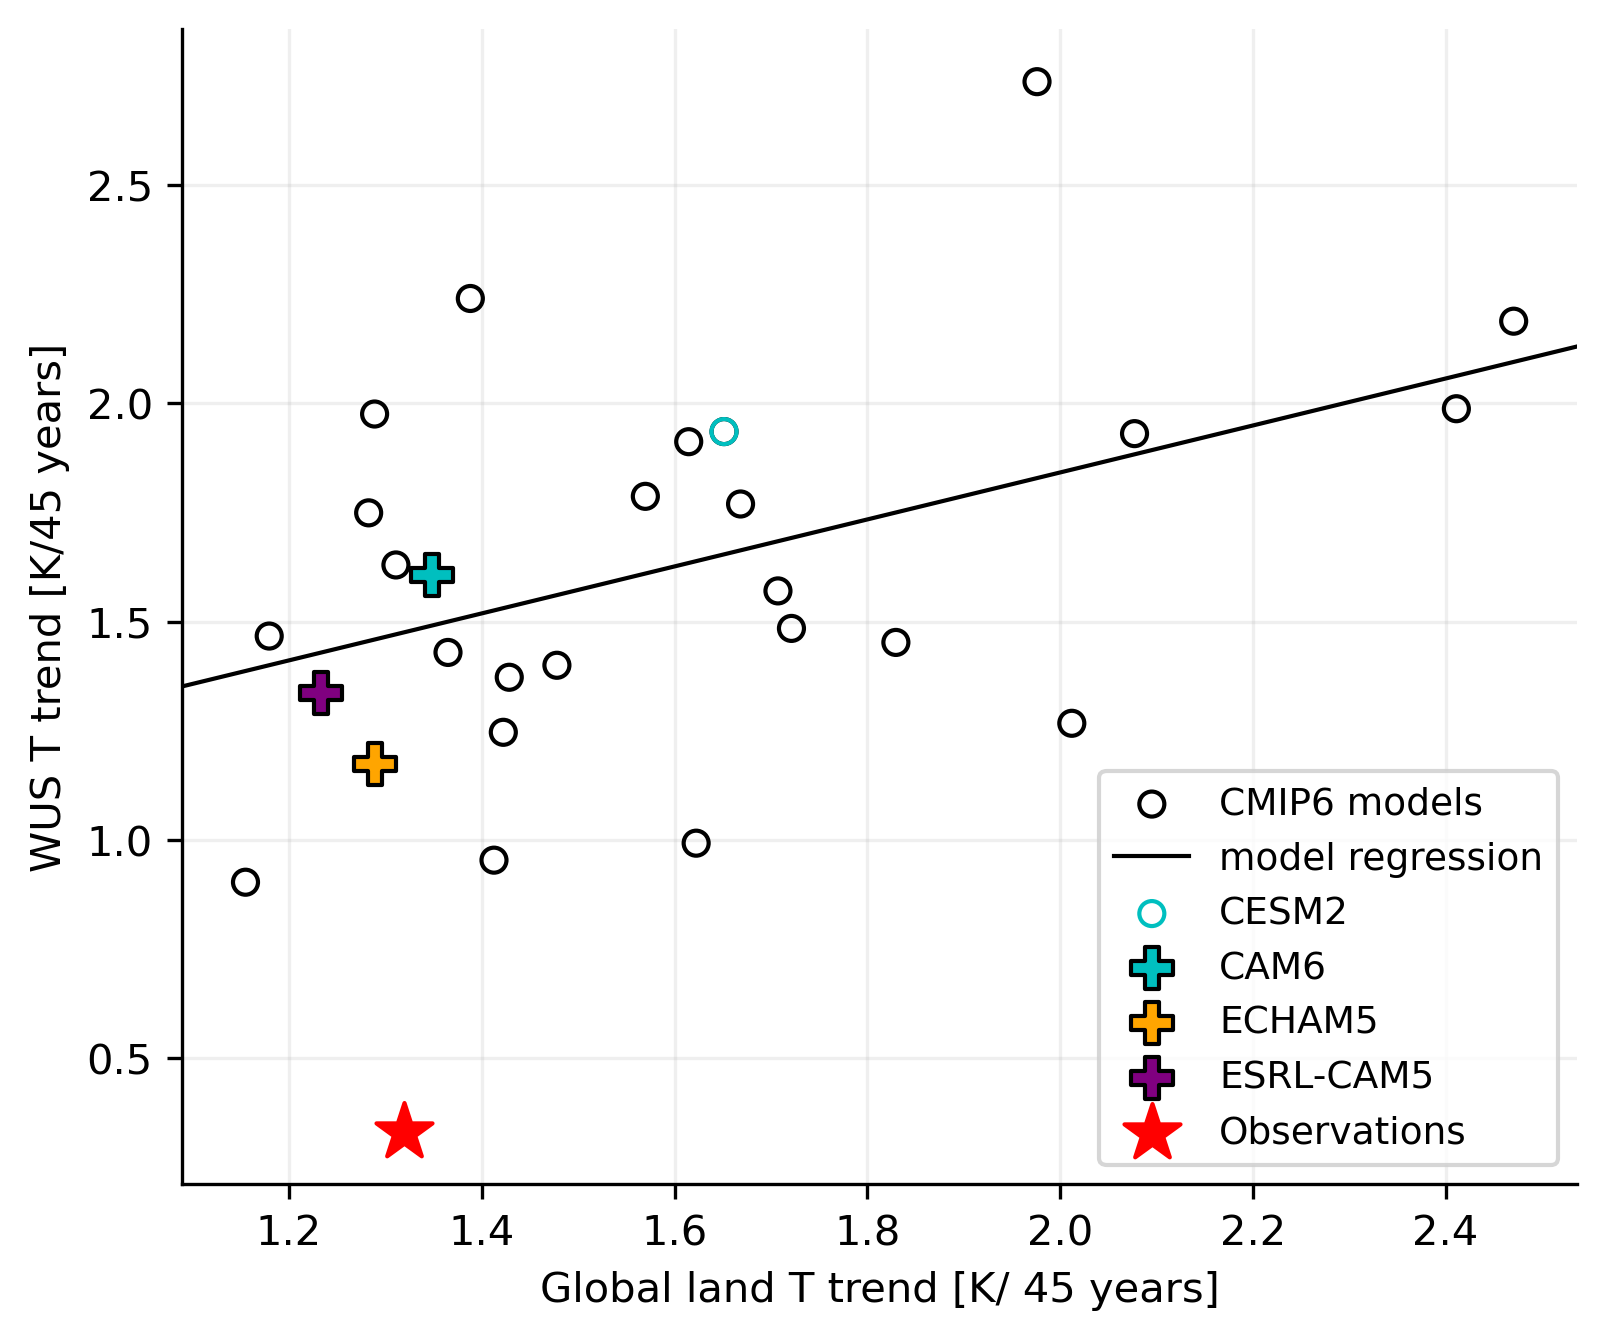

In [112]:
    fig, axes = plt.subplots(1,1, figsize=(6,5), dpi=300)
    
    ax = plt.subplot(1, 1,1)
    szn = 'JFM'
    
    ax.scatter(y=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients, x=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_globland_polyfit_coefficients, 
               marker='o', facecolors='none', zorder=100,edgecolor='k', label = 'CMIP6 models')
    sns.regplot(y=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients, x=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_globland_polyfit_coefficients, 
               truncate=False, ci=None, scatter=False, color='k', line_kws={'linewidth':1}, label='model regression')
        #if model.item() in single_run_models_tas:
        #    ax.scatter(y=smoothed_wus_bymodel_szn[szn][model.item()][74:85,1].mean(), x=smoothed_globland_bymodel_szn[szn][model.item()][74:85,1].mean(), marker='o', facecolors='none', edgecolor='grey')
    ax.scatter(y=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model='CESM2'), x=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_globland_polyfit_coefficients.sel(model='CESM2'), 
               marker='o', facecolors='none', zorder=100,edgecolor='c', label = 'CESM2')
    
    ax.scatter(y=45*cam6_ds_t2m_wus_avg_trend_ensmean_szn[szn].polyfit_coefficients, x=45*cam6_ds_t2m_globland_avg_trend_ensmean_szn[szn].polyfit_coefficients, s=100,  marker='P', c='c',edgecolor='k', label='CAM6',zorder=300)    
    #for member in cam6_ds_t2m_wus_avg_trend_szn[szn].member:
    #    ax.scatter(y=45*cam6_ds_t2m_wus_avg_trend_szn[szn].polyfit_coefficients, x=45*cam6_ds_t2m_globland_avg_trend_szn[szn].polyfit_coefficients, s=4,  c='c')            
    ax.scatter(y=45*echam5_ds_t2m_wus_avg_trend_ensmean_szn[szn].polyfit_coefficients, x=45*echam5_ds_t2m_globland_avg_trend_ensmean_szn[szn].polyfit_coefficients, s=100,  marker='P', c='orange',edgecolor='k', label='ECHAM5',zorder=300)    
            
    #for member in echam5_ds_t2m_globland_avg_trend_szn[szn].member:
    #    ax.scatter(y=45*echam5_ds_t2m_wus_avg_trend_szn[szn].polyfit_coefficients, x=45*echam5_ds_t2m_globland_avg_trend_szn[szn].polyfit_coefficients, s=4, c='orange')
    
    ax.scatter(y=45*esrl_ds_t2m_wus_avg_trend_ensmean_szn[szn].polyfit_coefficients, x=45*esrl_ds_t2m_globland_avg_trend_ensmean_szn[szn].polyfit_coefficients, s=100,  marker='P', c='purple',edgecolor='k', label='ESRL-CAM5',zorder=300)    
            
    #for member in esrl_ds_t2m_globland_avg_trend_szn[szn].member:
    #    ax.scatter(y=45*esrl_ds_t2m_wus_avg_trend_szn[szn].polyfit_coefficients, x=45*esrl_ds_t2m_globland_avg_trend_szn[szn].polyfit_coefficients, s=4, c='purple')

    #ax.scatter(y=smoothed_wus_szn[szn][74:85,1].mean(), x=smoothed_globland_szn[szn][74:85,1].mean(), marker='X', s=150, c='k', label='CMIP6 MMM')
    ax.scatter(y=45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, x=45*berk_temp_globland_avg_trend_szn[szn].temperature_polyfit_coefficients, s=200, c='r', marker='*', label='Observations')
    #ax.axhline(45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, c='r', ls='--', alpha=0.6)
    #ax.plot(np.arange(0,4), np.arange(0,4), c='k', label='1:1')


    ax.set_ylabel('WUS T trend [K/45 years]')
    ax.set_xlabel('Global land T trend [K/ 45 years]')
    ax.legend(fontsize=9)
    #ax.set_ylim([0,3])
    #ax.set_xlim(1,2.5)
    ax.grid(alpha=0.2) 
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #ax.set_title(f'{szn}')

In [13]:
szn = 'JFM'

scipy.stats.linregress(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients, ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_globland_polyfit_coefficients)

LinregressResult(slope=0.354796966074408, intercept=0.023216266693003522, rvalue=0.4368475030908197, pvalue=0.032807600453788874, stderr=0.15576039688848367, intercept_stderr=0.005868511676435165)

### plot panel a.

/tmp/ipykernel_30944/2467850795.py:30: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
/tmp/ipykernel_30944/2467850795.py:30: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
/tmp/ipykernel_30944/2467850795.py:30: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
/tmp/ipykernel_30944/2467850795.py:30: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly c

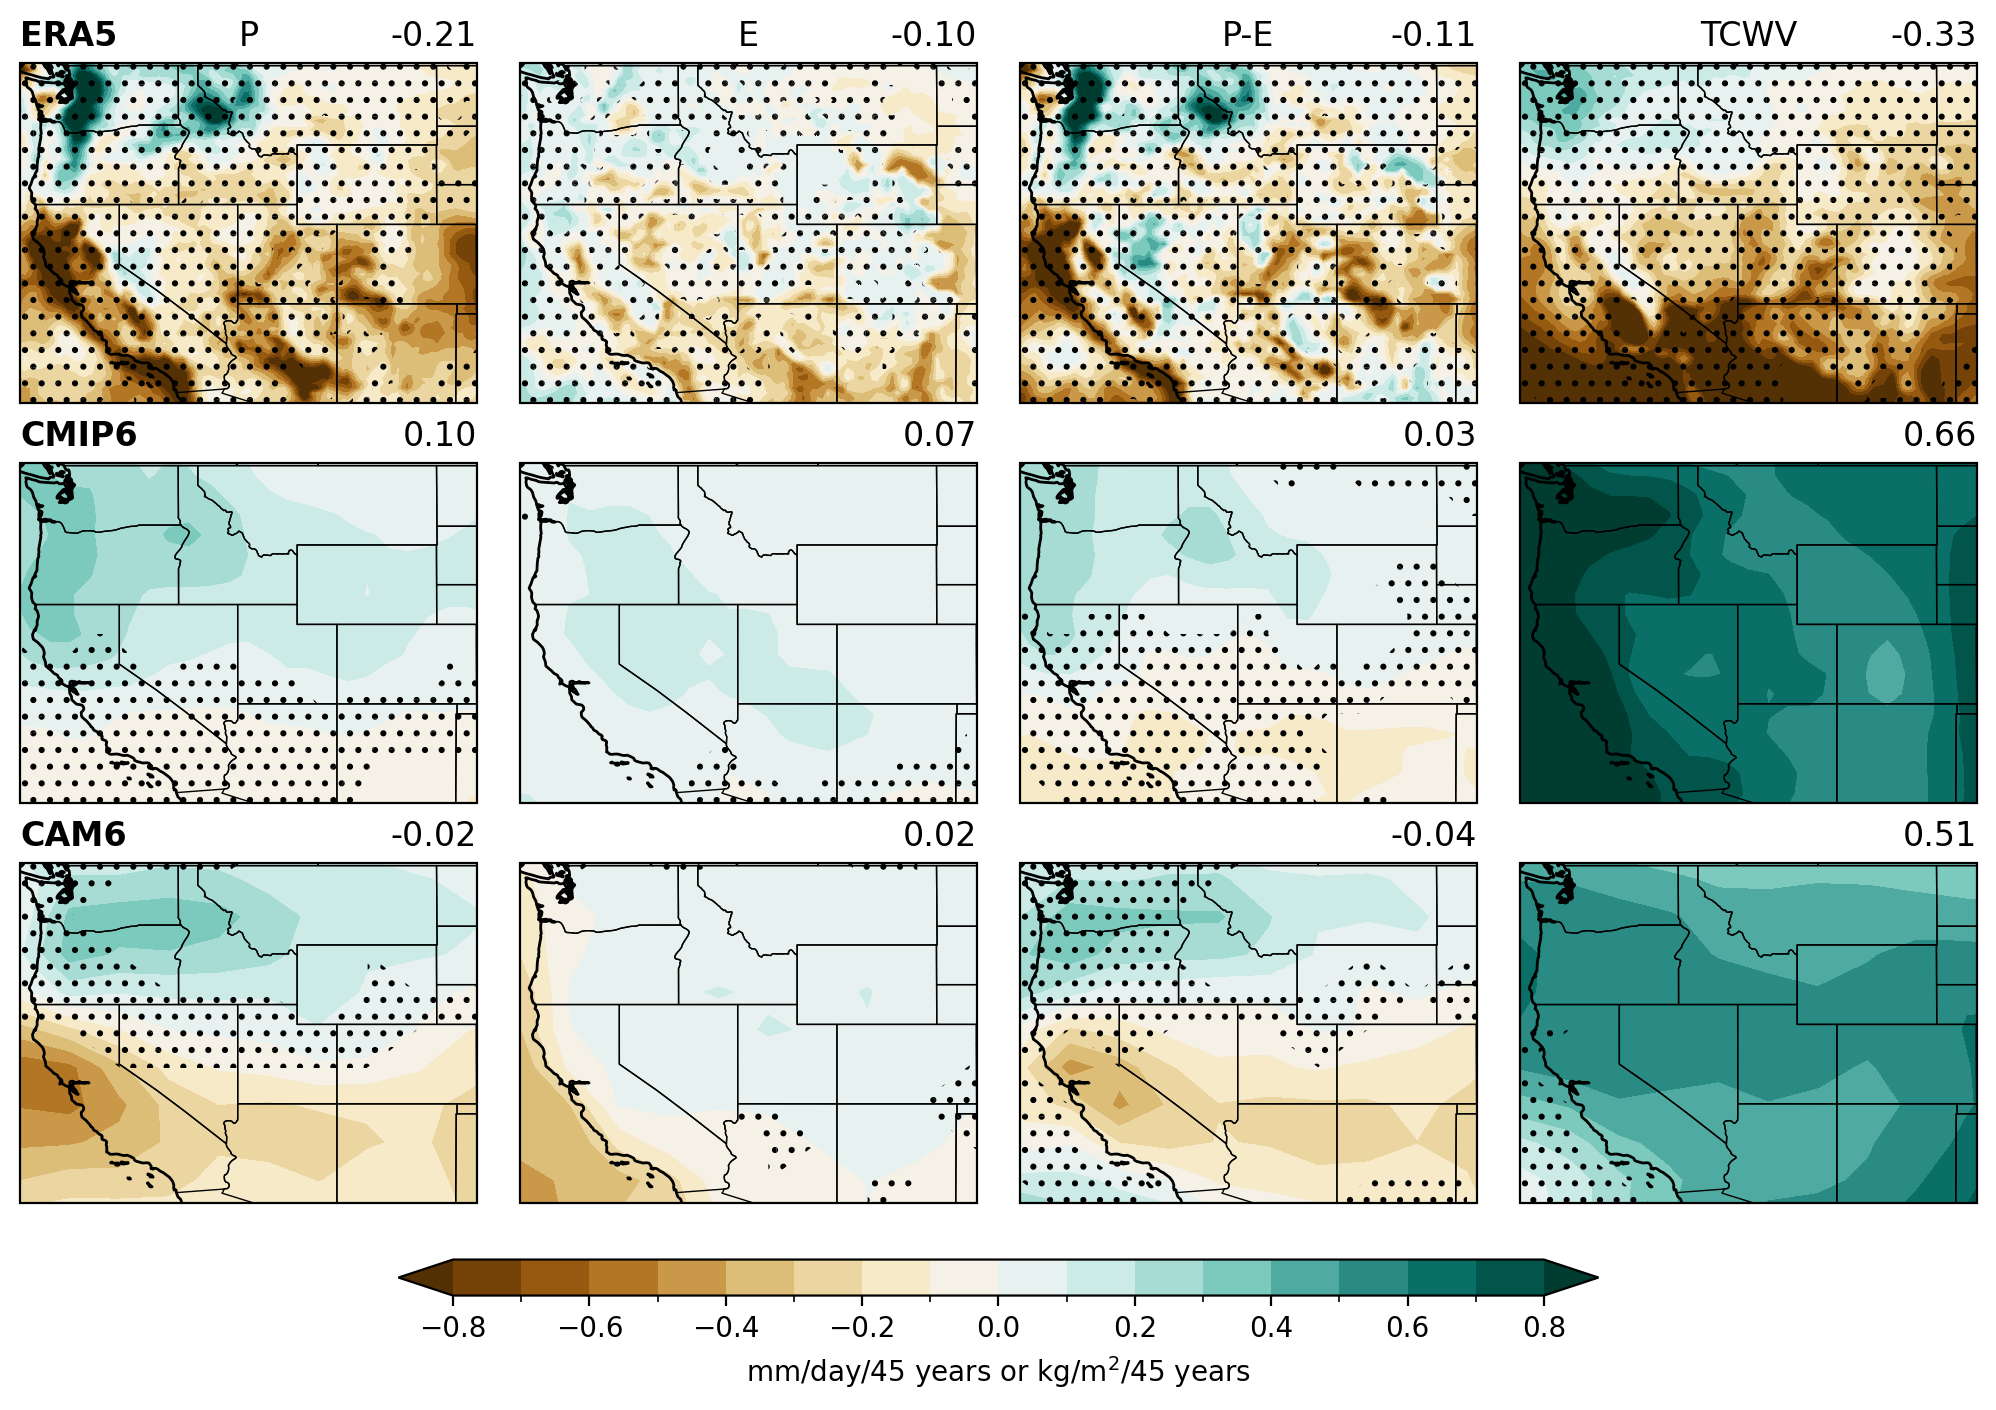

In [113]:
plt.rcParams['figure.constrained_layout.use'] = True
fig, axes = plt.subplots(3,4, figsize=(10,6), dpi=200)
models_plot_dss = [(86400*ds_pr_wus_51_80_m_anom_trend_szn['JFM']).pr_polyfit_coefficients.mean('model'), (ds_e_wus_51_80_m_anom_trend_szn['JFM']).e_polyfit_coefficients.mean('model'),
                   (86400*ds_pr_wus_51_80_m_anom_trend_szn['JFM']).pr_polyfit_coefficients.mean('model')- (ds_e_wus_51_80_m_anom_trend_szn['JFM']).e_polyfit_coefficients.mean('model'),
                  (ds_prw_wus_51_80_m_anom_trend_szn['JFM']).prw_polyfit_coefficients.mean('model')]
models_plot_dss_allens = [(86400*ds_pr_wus_51_80_m_anom_trend_szn['JFM']).pr_polyfit_coefficients, (ds_e_wus_51_80_m_anom_trend_szn['JFM']).e_polyfit_coefficients,
                   (86400*ds_pr_wus_51_80_m_anom_trend_szn['JFM']).pr_polyfit_coefficients- (ds_e_wus_51_80_m_anom_trend_szn['JFM']).e_polyfit_coefficients,
                  (ds_prw_wus_51_80_m_anom_trend_szn['JFM']).prw_polyfit_coefficients]

era5_plot_pvalues_dss = [era5_sl_wus_51_80_m_anom_trend_pvalue_szn['JFM'].tp, era5_sl_wus_51_80_m_anom_trend_pvalue_szn['JFM'].e, 
                 era5_pme_wus_51_80_m_anom_trend_pvalue_szn['JFM'], 
                 era5_sl_wus_51_80_m_anom_trend_pvalue_szn['JFM'].tcwv]

era5_plot_dss = [era5_sl_wus_51_80_m_anom_trend_szn['JFM'].tp_polyfit_coefficients, -1*era5_sl_wus_51_80_m_anom_trend_szn['JFM'].e_polyfit_coefficients, 
                 era5_sl_wus_51_80_m_anom_trend_szn['JFM'].tp_polyfit_coefficients + era5_sl_wus_51_80_m_anom_trend_szn['JFM'].e_polyfit_coefficients, 
                 era5_sl_wus_51_80_m_anom_trend_szn['JFM'].tcwv_polyfit_coefficients]

cam6_plot_dss = [(86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients.mean('member'), (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients.mean('member'),
                   (86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients.mean('member')- (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients.mean('member'),
                  (cam6_prw_wus_trend_szn['JFM']).polyfit_coefficients.mean('member')]
cam6_plot_dss_allens = [(86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients, (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients,
                   (86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients- (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients,
                  (cam6_prw_wus_trend_szn['JFM']).polyfit_coefficients]

titles = ['P', 'E','P-E', 'TCWV']
vmaxes = [.8, .8, .8,.8]
vmins = [-.8, -.8, -.8,-.8]
cmaps = ['BrBG', 'BrBG', 'BrBG','BrBG', 'BrBG']
for ii, ax in enumerate(axes.flatten()):
    ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
    if ii<4:
        (era5_plot_dss[ii]*45).plot.contourf(vmax=vmaxes[ii], vmin=vmins[ii],levels=17,extend='both', cmap=cmaps[ii], add_colorbar=False)
        era5_plot_pvalues_dss[ii].where(era5_plot_pvalues_dss[ii] >= .1).plot.contourf(hatches=['..'], colors='none', transform=ccrs.PlateCarree(), add_colorbar=False)
        ax.set_title(titles[ii], loc='center')
        wus_avg = (era5_plot_dss[ii]*45).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).where(landmask==landmask).weighted(era5_weights).mean(['lon', 'lat']).item()
        ax.set_title(f'{wus_avg:.2f}', loc='right')
        
        
    if ii==0: ax.set_title('ERA5',fontweight='bold', loc='left')

    elif (8>ii>=4):
        dstest = models_plot_dss_allens[ii-4]
        dstest_mmm = dstest.mean('model')
        dstest_samesign_mmm = dstest*dstest_mmm
        dstest_samesign_mmm = dstest_samesign_mmm/(np.abs(dstest_samesign_mmm))
        dstest_samesign_mmm = dstest_samesign_mmm.where(dstest_samesign_mmm==1, 0).sum('model')


        (models_plot_dss[ii-4]*45).plot.contourf(vmax=vmaxes[ii-4], vmin=vmins[ii-4], levels=17, extend='both', cmap=cmaps[ii-4], add_colorbar=False)
        dstest_samesign_mmm.where(dstest_samesign_mmm <= len(dstest.model)*.75).plot.contourf(hatches=['..'], colors='none', transform=ccrs.PlateCarree(), add_colorbar=False)

        ax.set_title('', fontweight='bold', loc='center')
        wus_avg = (models_plot_dss[ii-4]*45).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).where(landmask==landmask).weighted(weights).mean(['lon', 'lat']).item()
        ax.set_title(f'{wus_avg:.2f}', loc='right')

    if ii==4: ax.set_title('CMIP6',fontweight='bold',  loc='left')
        
    elif ii>=8:
        dstest = cam6_plot_dss_allens[ii-8]
        dstest_mmm = dstest.mean('member')
        dstest_samesign_mmm = dstest*dstest_mmm
        dstest_samesign_mmm = dstest_samesign_mmm/(np.abs(dstest_samesign_mmm))
        dstest_samesign_mmm = dstest_samesign_mmm.where(dstest_samesign_mmm==1, 0).sum('member')


        im=(cam6_plot_dss[ii-8]*45).plot.contourf(vmax=vmaxes[ii-8], vmin=vmins[ii-8], levels=17, extend='both', cmap=cmaps[ii-8], add_colorbar=False)
        dstest_samesign_mmm.where(dstest_samesign_mmm <= len(dstest.member)*.75).plot.contourf(hatches=['..'], colors='none', transform=ccrs.PlateCarree(), add_colorbar=False)

        ax.set_title('', fontweight='bold', loc='center')
        wus_avg = (cam6_plot_dss[ii-8]*45).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).where(cam6_landmask==cam6_landmask).weighted(cam6_ds_e_weights).mean(['lon', 'lat']).item()
        ax.set_title(f'{wus_avg:.2f}', loc='right')
        
    if ii==8: ax.set_title('CAM6',fontweight='bold', loc='left')

    #ax.set_title('', fontweight='bold', loc='center')
                                                                      
    #if ii==0:
    #    ax.text(x=-128, y=30, s='CMIP6 MMM', rotation=90, fontsize=8, weight ='bold')
    #    ax.text(x=-128, y=10, s='ERA5', rotation=90, fontsize=8, weight ='bold')     
    ax.set_extent([-125, -102, 32, 49])
    ax.coastlines(lw=1)
    ax.add_feature(cartopy.feature.STATES, lw=0.5)

ax2 = fig.add_axes((.2,-.07,.6,.03))
plt.colorbar(im, cax=ax2, shrink=0.6, orientation='horizontal', label='mm/day/45 years or kg/m$^2$/45 years')

#plt.suptitle('1980-2024 JFM trends')

### Check trends ending in 2021

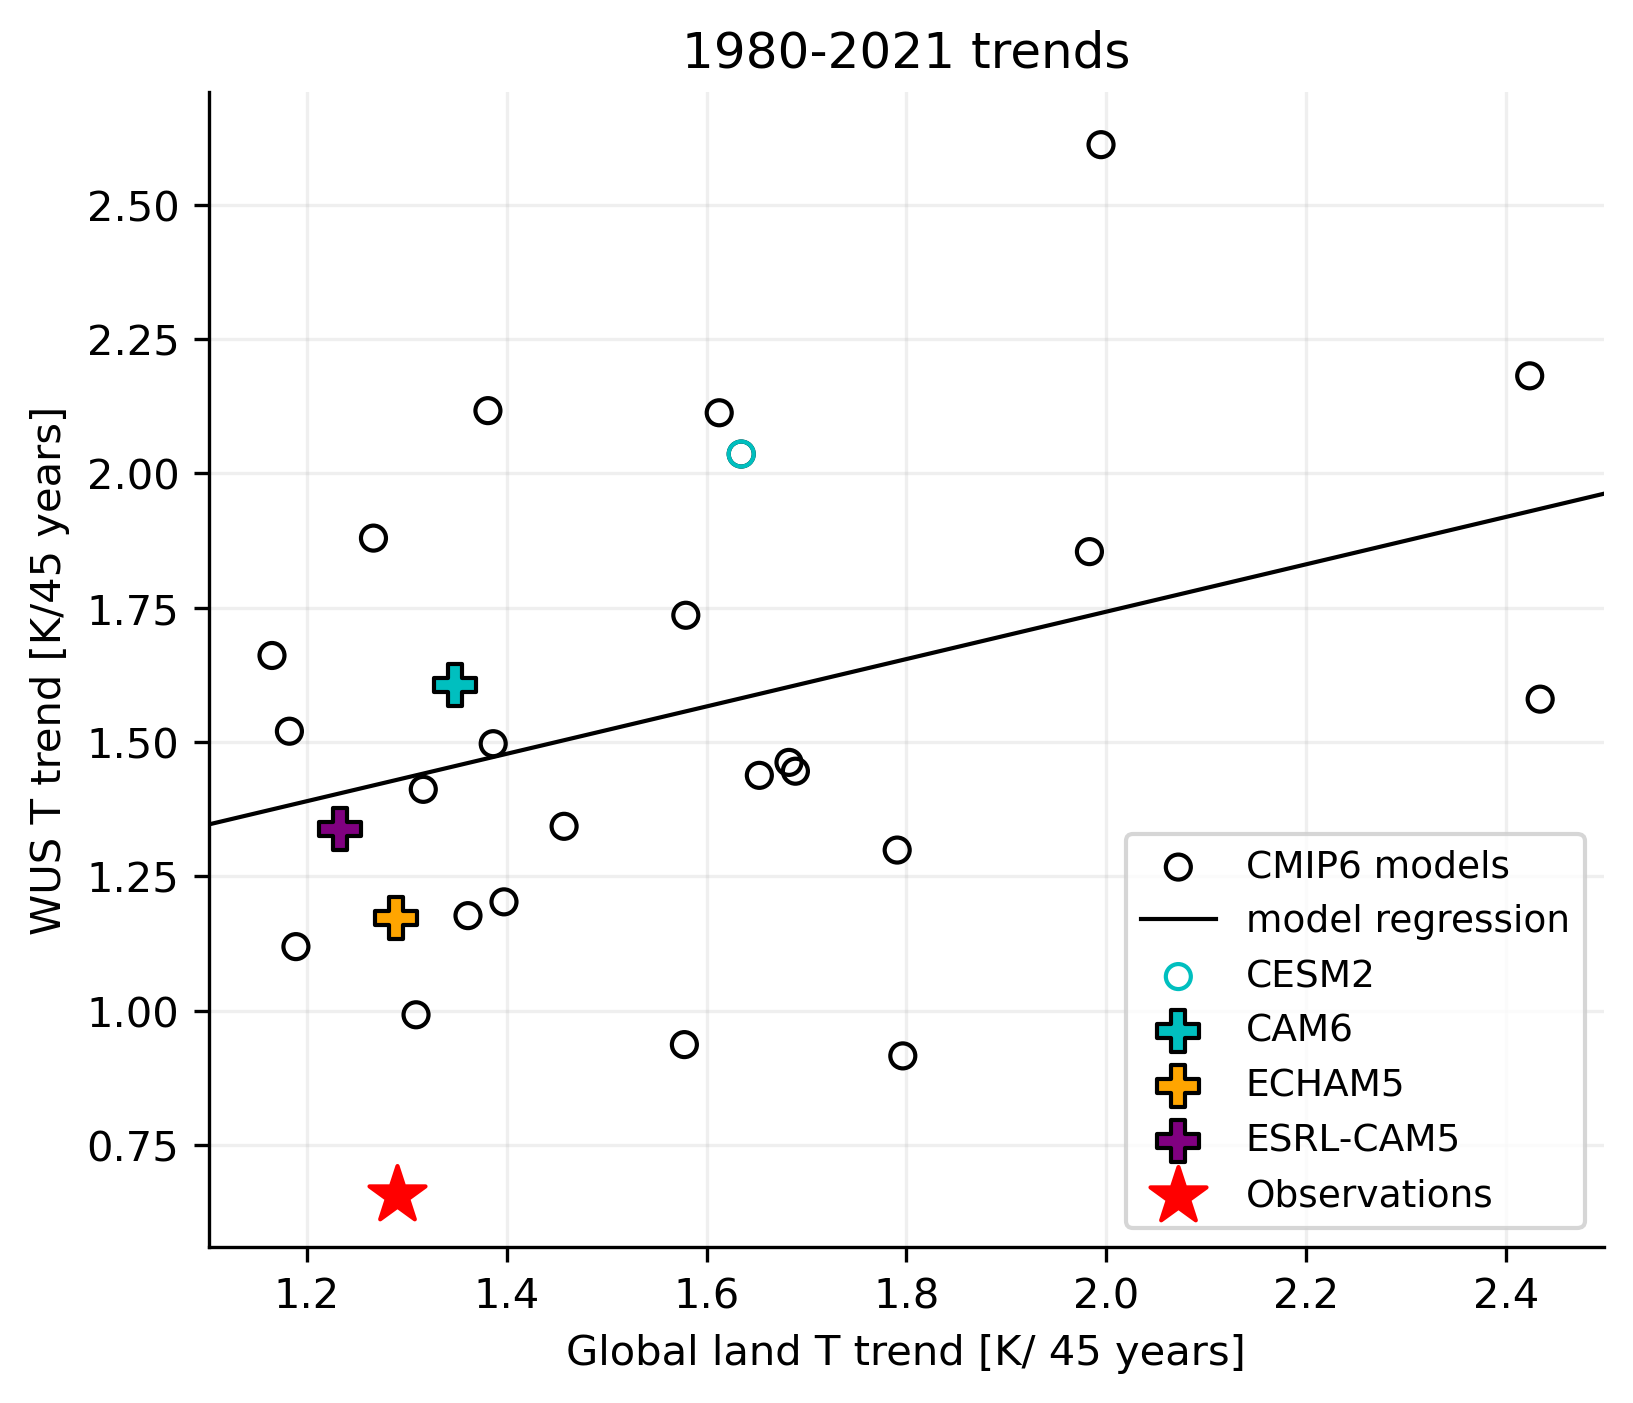

In [122]:
    # 2021 end
    fig, axes = plt.subplots(1,1, figsize=(6,5), dpi=300)
    
    ax = plt.subplot(1, 1,1)
    szn = 'JFM'
    
    ax.scatter(y=45*ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn].tas_wus_polyfit_coefficients, x=45*ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn].tas_globland_polyfit_coefficients, 
               marker='o', facecolors='none', zorder=100,edgecolor='k', label = 'CMIP6 models')
    sns.regplot(y=45*ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn].tas_wus_polyfit_coefficients, x=45*ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn].tas_globland_polyfit_coefficients, 
               truncate=False, ci=None, scatter=False, color='k', line_kws={'linewidth':1}, label='model regression')
        #if model.item() in single_run_models_tas:
        #    ax.scatter(y=smoothed_wus_bymodel_szn[szn][model.item()][74:85,1].mean(), x=smoothed_globland_bymodel_szn[szn][model.item()][74:85,1].mean(), marker='o', facecolors='none', edgecolor='grey')
    ax.scatter(y=45*ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn].tas_wus_polyfit_coefficients.sel(model='CESM2'), x=45*ds_tas_avg_51_80_m_anom_trend_szn_2021end[szn].tas_globland_polyfit_coefficients.sel(model='CESM2'), 
               marker='o', facecolors='none', zorder=100,edgecolor='c', label = 'CESM2')
    
    ax.scatter(y=45*cam6_ds_t2m_wus_avg_trend_ensmean_szn[szn].polyfit_coefficients, x=45*cam6_ds_t2m_globland_avg_trend_ensmean_szn[szn].polyfit_coefficients, s=100,  marker='P', c='c',edgecolor='k', label='CAM6',zorder=300)    
    #for member in cam6_ds_t2m_wus_avg_trend_szn[szn].member:
    #    ax.scatter(y=45*cam6_ds_t2m_wus_avg_trend_szn[szn].polyfit_coefficients, x=45*cam6_ds_t2m_globland_avg_trend_szn[szn].polyfit_coefficients, s=4,  c='c')            
    ax.scatter(y=45*echam5_ds_t2m_wus_avg_trend_ensmean_szn[szn].polyfit_coefficients, x=45*echam5_ds_t2m_globland_avg_trend_ensmean_szn[szn].polyfit_coefficients, s=100,  marker='P', c='orange',edgecolor='k', label='ECHAM5',zorder=300)    
            
    #for member in echam5_ds_t2m_globland_avg_trend_szn[szn].member:
    #    ax.scatter(y=45*echam5_ds_t2m_wus_avg_trend_szn[szn].polyfit_coefficients, x=45*echam5_ds_t2m_globland_avg_trend_szn[szn].polyfit_coefficients, s=4, c='orange')
    
    ax.scatter(y=45*esrl_ds_t2m_wus_avg_trend_ensmean_szn[szn].polyfit_coefficients, x=45*esrl_ds_t2m_globland_avg_trend_ensmean_szn[szn].polyfit_coefficients, s=100,  marker='P', c='purple',edgecolor='k', label='ESRL-CAM5',zorder=300)    
            
    #for member in esrl_ds_t2m_globland_avg_trend_szn[szn].member:
    #    ax.scatter(y=45*esrl_ds_t2m_wus_avg_trend_szn[szn].polyfit_coefficients, x=45*esrl_ds_t2m_globland_avg_trend_szn[szn].polyfit_coefficients, s=4, c='purple')

    #ax.scatter(y=smoothed_wus_szn[szn][74:85,1].mean(), x=smoothed_globland_szn[szn][74:85,1].mean(), marker='X', s=150, c='k', label='CMIP6 MMM')
    ax.scatter(y=45*berk_temp_wus_avg_trend_szn_2021end[szn].temperature_polyfit_coefficients, x=45*berk_temp_globland_avg_trend_szn_2021end[szn].temperature_polyfit_coefficients, s=200, c='r', marker='*', label='Observations')
    #ax.axhline(45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, c='r', ls='--', alpha=0.6)
    #ax.plot(np.arange(0,4), np.arange(0,4), c='k', label='1:1')

    ax.set_title('1980-2021 trends')
    ax.set_ylabel('WUS T trend [K/45 years]')
    ax.set_xlabel('Global land T trend [K/ 45 years]')
    ax.legend(fontsize=9)
    #ax.set_ylim([0,3])
    #ax.set_xlim(1,2.5)
    ax.grid(alpha=0.2) 
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #ax.set_title(f'{szn}')

/tmp/ipykernel_30342/382332607.py:26: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
/tmp/ipykernel_30342/382332607.py:26: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
/tmp/ipykernel_30342/382332607.py:26: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
/tmp/ipykernel_30342/382332607.py:26: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call 

Text(0.5, 0.98, '1980-2021 JFM trends')

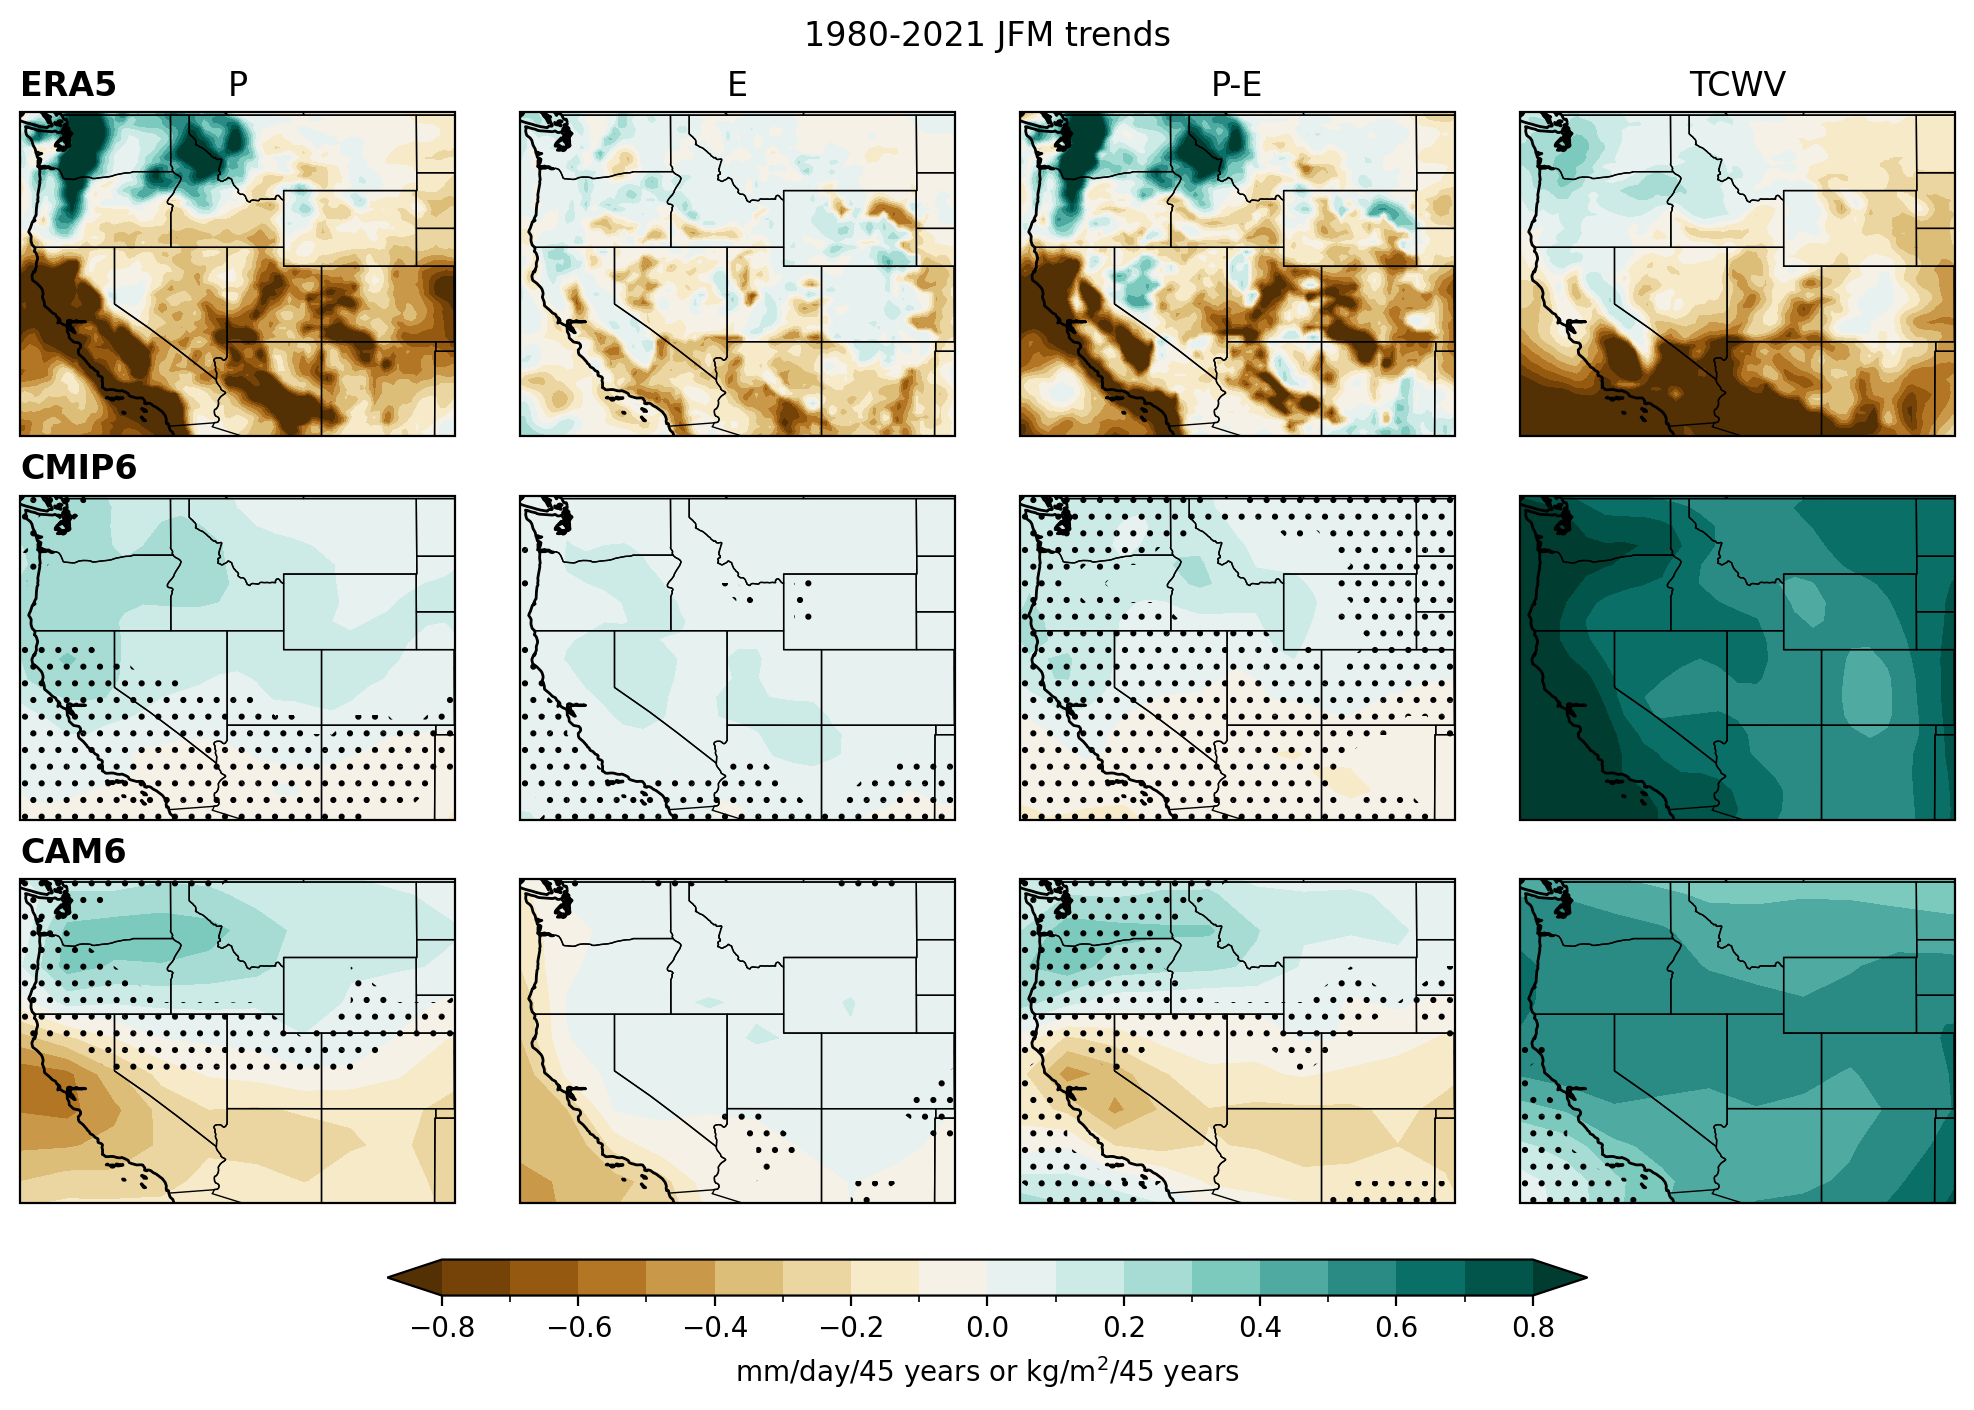

In [129]:
plt.rcParams['figure.constrained_layout.use'] = True
fig, axes = plt.subplots(3,4, figsize=(10,6), dpi=200)
models_plot_dss = [(86400*ds_pr_wus_51_80_m_anom_trend_szn_2021end['JFM']).pr_polyfit_coefficients.mean('model'), (ds_e_wus_51_80_m_anom_trend_szn_2021end['JFM']).e_polyfit_coefficients.mean('model'),
                   (86400*ds_pr_wus_51_80_m_anom_trend_szn_2021end['JFM']).pr_polyfit_coefficients.mean('model')- (ds_e_wus_51_80_m_anom_trend_szn_2021end['JFM']).e_polyfit_coefficients.mean('model'),
                  (ds_prw_wus_51_80_m_anom_trend_szn_2021end['JFM']).prw_polyfit_coefficients.mean('model')]
models_plot_dss_allens = [(86400*ds_pr_wus_51_80_m_anom_trend_szn_2021end['JFM']).pr_polyfit_coefficients, (ds_e_wus_51_80_m_anom_trend_szn_2021end['JFM']).e_polyfit_coefficients,
                   (86400*ds_pr_wus_51_80_m_anom_trend_szn_2021end['JFM']).pr_polyfit_coefficients- (ds_e_wus_51_80_m_anom_trend_szn_2021end['JFM']).e_polyfit_coefficients,
                  (ds_prw_wus_51_80_m_anom_trend_szn_2021end['JFM']).prw_polyfit_coefficients]

era5_plot_dss = [era5_sl_wus_51_80_m_anom_trend_szn_2021end['JFM'].tp_polyfit_coefficients, -1*era5_sl_wus_51_80_m_anom_trend_szn_2021end['JFM'].e_polyfit_coefficients, 
                 era5_sl_wus_51_80_m_anom_trend_szn_2021end['JFM'].tp_polyfit_coefficients + era5_sl_wus_51_80_m_anom_trend_szn_2021end['JFM'].e_polyfit_coefficients, 
                 era5_sl_wus_51_80_m_anom_trend_szn_2021end['JFM'].tcwv_polyfit_coefficients]

cam6_plot_dss = [(86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients.mean('member'), (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients.mean('member'),
                   (86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients.mean('member')- (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients.mean('member'),
                  (cam6_prw_wus_trend_szn['JFM']).polyfit_coefficients.mean('member')]
cam6_plot_dss_allens = [(86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients, (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients,
                   (86400000*cam6_ds_pr_wus_trend_szn['JFM']).polyfit_coefficients- (cam6_ds_e_wus_trend_szn['JFM']).polyfit_coefficients,
                  (cam6_prw_wus_trend_szn['JFM']).polyfit_coefficients]

titles = ['P', 'E','P-E', 'TCWV']
vmaxes = [.8, .8, .8,.8]
vmins = [-.8, -.8, -.8,-.8]
cmaps = ['BrBG', 'BrBG', 'BrBG','BrBG', 'BrBG']
for ii, ax in enumerate(axes.flatten()):
    ax = plt.subplot(3, 4,ii+1, projection=ccrs.PlateCarree())
    if ii<4:
        (era5_plot_dss[ii]*45).plot.contourf(vmax=vmaxes[ii], vmin=vmins[ii],levels=17,extend='both', cmap=cmaps[ii], add_colorbar=False)
        ax.set_title(titles[ii], loc='center')
        
        
        
    if ii==0: ax.set_title('ERA5',fontweight='bold', loc='left')

    elif (8>ii>=4):
        dstest = models_plot_dss_allens[ii-4]
        dstest_mmm = dstest.mean('model')
        dstest_samesign_mmm = dstest*dstest_mmm
        dstest_samesign_mmm = dstest_samesign_mmm/(np.abs(dstest_samesign_mmm))
        dstest_samesign_mmm = dstest_samesign_mmm.where(dstest_samesign_mmm==1, 0).sum('model')


        (models_plot_dss[ii-4]*45).plot.contourf(vmax=vmaxes[ii-4], vmin=vmins[ii-4], levels=17, extend='both', cmap=cmaps[ii-4], add_colorbar=False)
        dstest_samesign_mmm.where(dstest_samesign_mmm <= 18).plot.contourf(hatches=['..'], colors='none', transform=ccrs.PlateCarree(), add_colorbar=False)

        ax.set_title('', fontweight='bold', loc='center')

    if ii==4: ax.set_title('CMIP6',fontweight='bold',  loc='left')
        
    elif ii>=8:
        dstest = cam6_plot_dss_allens[ii-8]
        dstest_mmm = dstest.mean('member')
        dstest_samesign_mmm = dstest*dstest_mmm
        dstest_samesign_mmm = dstest_samesign_mmm/(np.abs(dstest_samesign_mmm))
        dstest_samesign_mmm = dstest_samesign_mmm.where(dstest_samesign_mmm==1, 0).sum('member')


        im=(cam6_plot_dss[ii-8]*45).plot.contourf(vmax=vmaxes[ii-8], vmin=vmins[ii-8], levels=17, extend='both', cmap=cmaps[ii-8], add_colorbar=False)
        dstest_samesign_mmm.where(dstest_samesign_mmm <= 12).plot.contourf(hatches=['..'], colors='none', transform=ccrs.PlateCarree(), add_colorbar=False)

        ax.set_title('', fontweight='bold', loc='center')
        
    if ii==8: ax.set_title('CAM6',fontweight='bold', loc='left')

    #ax.set_title('', fontweight='bold', loc='center')
                                                                      
    #if ii==0:
    #    ax.text(x=-128, y=30, s='CMIP6 MMM', rotation=90, fontsize=8, weight ='bold')
    #    ax.text(x=-128, y=10, s='ERA5', rotation=90, fontsize=8, weight ='bold')     
    ax.set_extent([-125, -102, 32, 49])
    ax.coastlines(lw=1)
    ax.add_feature(cartopy.feature.STATES, lw=0.5)

ax2 = fig.add_axes((.2,-.07,.6,.03))
plt.colorbar(im, cax=ax2, shrink=0.6, orientation='horizontal', label='mm/day/45 years or kg/m$^2$/45 years')

plt.suptitle('1980-2021 JFM trends')